In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Load and preprocess MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

In [3]:
# Convert labels to categorical (one-hot encoding)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

## Encoder Architecture:

- The encoder consists of three convolutional layers with increasing numbers of filters (32, 64, 128), each followed by batch normalization to stabilize and accelerate training.
- The output from the convolutional layers is flattened and passed through a dense layer with 128 units.
- Dropout is added to the dense layer to prevent overfitting.
- The final dense layer has 10 units with a softmax activation function for classification.

In [4]:
# Define the encoder model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


c:\Users\mishr\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Compile the model
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy', 
                       tf.keras.metrics.Precision(name='precision'), 
                       tf.keras.metrics.Recall(name='recall')])

# Implement early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [6]:
# Train the model
history = model.fit(x_train, y_train, 
                    epochs=50, 
                    validation_data=(x_test, y_test), 
                    callbacks=[early_stopping])


Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 224s 117ms/step - accuracy: 0.7767 - loss: 1.0466 - precision: 0.8545 - recall: 0.7285 - val_accuracy: 0.9680 - val_loss: 0.1444 - val_precision: 0.9770 - val_recall: 0.9583
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 232s 124ms/step - accuracy: 0.9145 - loss: 0.3251 - precision: 0.9532 - recall: 0.8918 - val_accuracy: 0.9798 - val_loss: 0.1055 - val_precision: 0.9831 - val_recall: 0.9773
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 368s 196ms/step - accuracy: 0.9450 - loss: 0.2125 - precision: 0.9687 - recall: 0.9326 - val_accuracy: 0.9843 - val_loss: 0.0622 - val_precision: 0.9895 - val_recall: 0.9795
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 254s 136ms/step - accuracy: 0.9576 - loss: 0.1582 - precision: 0.9741 - recall: 0.9472 - val_accuracy: 0.9857 - val_loss: 0.0720 - val_precision: 0.9888 - val_recall: 0.9826
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 264s 141ms/step - accuracy: 0.9671 - loss: 0.1240 - precision: 0.9795 - recall: 0.9584 - val_a

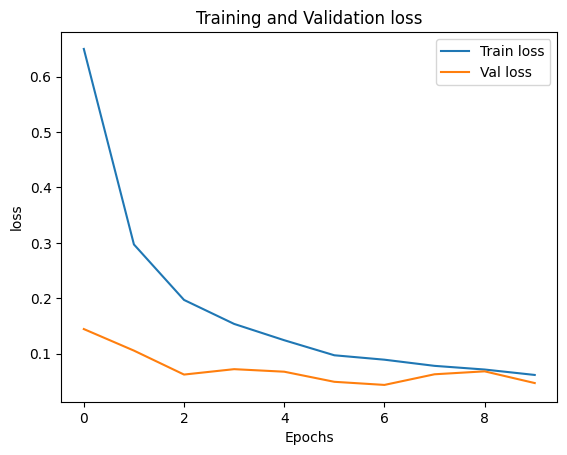

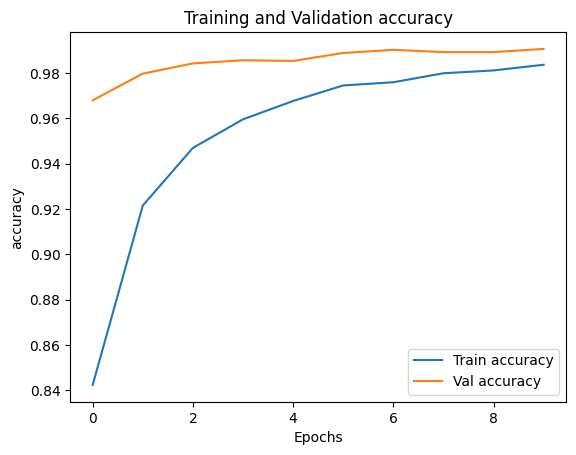

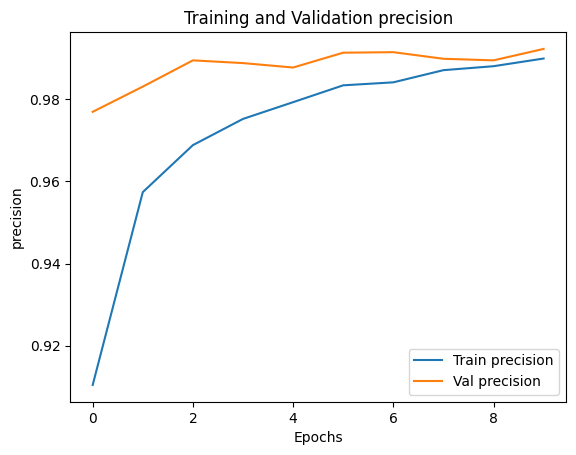

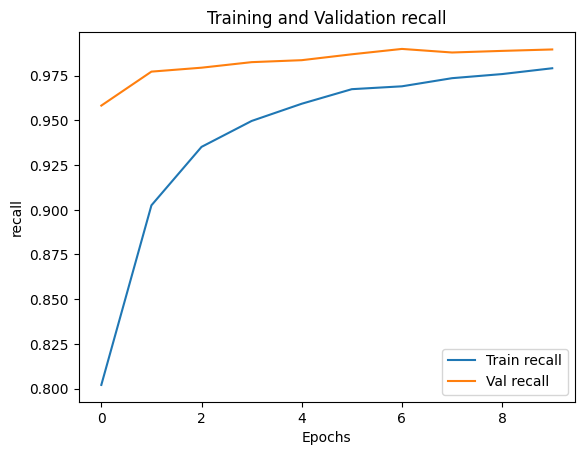

In [7]:
# Plotting training & validation metrics
def plot_metrics(history):
    metrics = ['loss', 'accuracy', 'precision', 'recall']
    for metric in metrics:
        plt.plot(history.history[metric], label=f'Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'Val {metric}')
        plt.title(f'Training and Validation {metric}')
        plt.xlabel('Epochs')
        plt.ylabel(metric)
        plt.legend()
        plt.show()

plot_metrics(history)

In [8]:
# Evaluate the model
results = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")
print(f"Test Precision: {results[2]}")
print(f"Test Recall: {results[3]}")

Test Loss: 0.04354317486286163
Test Accuracy: 0.9902999997138977
Test Precision: 0.9914872050285339
Test Recall: 0.9900000095367432


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 22, 22, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,073,632 (91.83 MB)

 Trainable params: 8,024,394 (30.61 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 16,048,790 (61.22 MB)

In [ ]:
model.save("SimpleRNNwithEarlyStopping.keras")